In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import os
import glob
from scipy.stats import gamma
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("df_full/PWAT_data.csv")

In [ ]:
# %%bash
# ncdump -h /shared_space/ACV/extracted_raw/mag_dir/mag_dir197910.nc

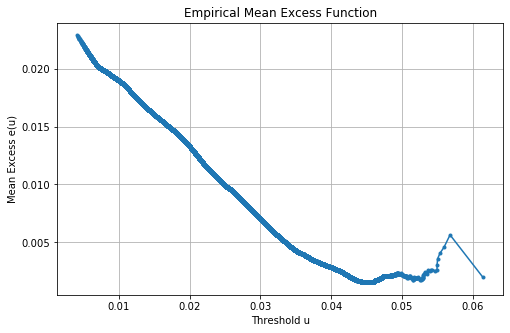

In [5]:
# Take the first 100,000 rows using slicing
df_first_100k = df[:100000]
damage = df_first_100k["PWAT"].sort_values().values  # Sort the damage values - Now these are temp values but I didnt change the varable

# Define the empirical excess function
mean_excess = []
thresholds = damage  # Use each value as a threshold

for u in thresholds:
    exceedances = damage[damage > u]
    if len(exceedances) > 0:
        mean_excess.append(np.mean(exceedances - u))
    else:
        mean_excess.append(np.nan)  # No exceedances

# Plot the mean excess function
plt.figure(figsize=(8, 5))
plt.plot(thresholds, mean_excess, marker='o', linestyle='-', markersize=3)
plt.xlabel("Threshold u")
plt.ylabel("Mean Excess e(u)")
plt.title("Empirical Mean Excess Function")
plt.grid()
plt.show()

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:5: RuntimeWarning: invalid value encountered in less_equal
  """


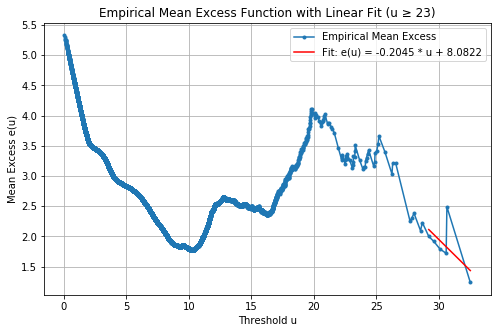

Slope: -0.2045
Intercept: 8.0822


In [9]:
from scipy.stats import linregress

thresholds = np.array(thresholds)
mean_excess = np.array(mean_excess)
mask = (thresholds >= 29) & (mean_excess <=25) # edit for each variable based on above graph
x_fit = thresholds[mask]
y_fit = mean_excess[mask]


# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(x_fit, y_fit)

# Plot the mean excess function
plt.figure(figsize=(8, 5))
plt.plot(thresholds, mean_excess, marker='o', linestyle='-', markersize=3, label="Empirical Mean Excess")
plt.plot(x_fit, slope * x_fit + intercept, color='red', label=f"Fit: e(u) = {slope:.4f} * u + {intercept:.4f}")
plt.xlabel("Threshold u")
plt.ylabel("Mean Excess e(u)")
plt.title("Empirical Mean Excess Function with Linear Fit (u ≥ 29)")
plt.legend()
plt.grid()
plt.show()

# Report the slope and intercept
print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")

In [11]:
# Calculate shape and scale parameters
shape_parameter = slope / (1 + slope)
scale_parameter = intercept * (1 - shape_parameter)
print(f"Shape Parameter: {shape_parameter:.4f}")
print(f"Scale Parameter: {scale_parameter:.4f}")

Shape Parameter: -0.2570
Scale Parameter: 10.1596


In [ ]:
#value at risk

In [12]:

# Given parameter estimates
xi = shape_parameter  # Shape parameter
phi = scale_parameter  # Scale parameter
p = 0.95  # Confidence level

hazard = np.array(df["Wind"]) 

# Compute 95th percentile threshold
u = np.percentile(hazard, 95)

# Total number of observations
n = len(hazard)

# Number of exceedances above threshold
N_u = np.sum(hazard > u)

# Compute VaR_0.95 using the given formula
VaR_95 = u + (phi / xi) * (((n / N_u) * (1 - p)) ** (-xi) - 1)

print(f"95% Value at Risk (VaR_0.95): {VaR_95:.4f}")
#value is a little further then my estimates

95% Value at Risk (VaR_0.95): 10.0206


In [ ]:
#conditional value at risk

In [13]:
if xi < 1:  # Condition for expectation to be finite
    CVaR_95 = VaR_95 + (phi + xi * (VaR_95 - u)) / (1 - xi)
    print(f"95% Conditional Value at Risk (CVaR_0.95): {CVaR_95:.4f}")
else:
    print("CVaR is undefined for ξ ≥ 1 as expected shortfall is infinite.")

95% Conditional Value at Risk (CVaR_0.95): 18.1028


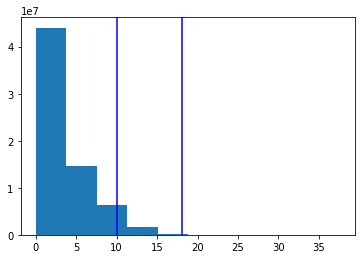

In [14]:
plt.hist(hazard)

plt.axvline(x = VaR_95, color = 'b', label = 'axvline - full height')
plt.axvline(x = CVaR_95, color = 'b', label = 'axvline - full height')
 
plt.show() 